Importar librerias

In [ ]:
!pip install keras_preprocessing

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.3 MB/s eta 0:00:00


In [ ]:
import tensorflow
import pandas as pd
import numpy as np

from keras.models import Sequential
from keras import optimizers
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras_preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import SGD

In [ ]:
!pip install gdown

In [ ]:
import gdown
url = "https://drive.google.com/uc?id=1l9bQc1judK50br5_lmboabsiPw0fBV43&export=download"
output = "/content/HAM1000_images.zip"

gdown.download(url, output)

Downloading...
From: https://drive.google.com/uc?id=1l9bQc1judK50br5_lmboabsiPw0fBV43&export=download
To: /content/HAM1000_images.zip
100%|██████████| 2.78G/2.78G [00:28<00:00, 97.4MB/s]


'/content/HAM1000_images.zip'

In [ ]:
url = "https://drive.google.com/uc?id=16QcdAOVuqoJo2FT0xRvsaGFGV5YBy3SL"
output = "/content/HAM10000_metadata.csv"

gdown.download(url, output)

Downloading...
From: https://drive.google.com/uc?id=16QcdAOVuqoJo2FT0xRvsaGFGV5YBy3SL
To: /content/HAM10000_metadata.csv
100%|██████████| 563k/563k [00:00<00:00, 57.2MB/s]


'/content/HAM10000_metadata.csv'

In [ ]:
!unzip '/content/HAM1000_images.zip' -d '/content/'

Se han truncado las últimas 5000 líneas del flujo de salida.
  inflating: /content/__MACOSX/HAM1000_images/._ISIC_0030879.jpg  
  inflating: /content/HAM1000_images/ISIC_0028788.jpg  
  inflating: /content/__MACOSX/HAM1000_images/._ISIC_0028788.jpg  
  inflating: /content/HAM1000_images/ISIC_0029496.jpg  
  inflating: /content/__MACOSX/HAM1000_images/._ISIC_0029496.jpg  
  inflating: /content/HAM1000_images/ISIC_0028950.jpg  
  inflating: /content/__MACOSX/HAM1000_images/._ISIC_0028950.jpg  
  inflating: /content/HAM1000_images/ISIC_0032908.jpg  
  inflating: /content/__MACOSX/HAM1000_images/._ISIC_0032908.jpg  
  inflating: /content/HAM1000_images/ISIC_0026969.jpg  
  inflating: /content/__MACOSX/HAM1000_images/._ISIC_0026969.jpg  
  inflating: /content/HAM1000_images/ISIC_0029482.jpg  
  inflating: /content/__MACOSX/HAM1000_images/._ISIC_0029482.jpg  
  inflating: /content/HAM1000_images/ISIC_0028944.jpg  
  inflating: /content/__MACOSX/HAM1000_images/._ISIC_0028944.jpg  
  inflating

Cargar datos

In [ ]:
dataset = pd.read_csv('HAM10000_metadata.csv')
dataset['image_full_name'] = dataset['image_id']+'.jpg'

Creación del modelo

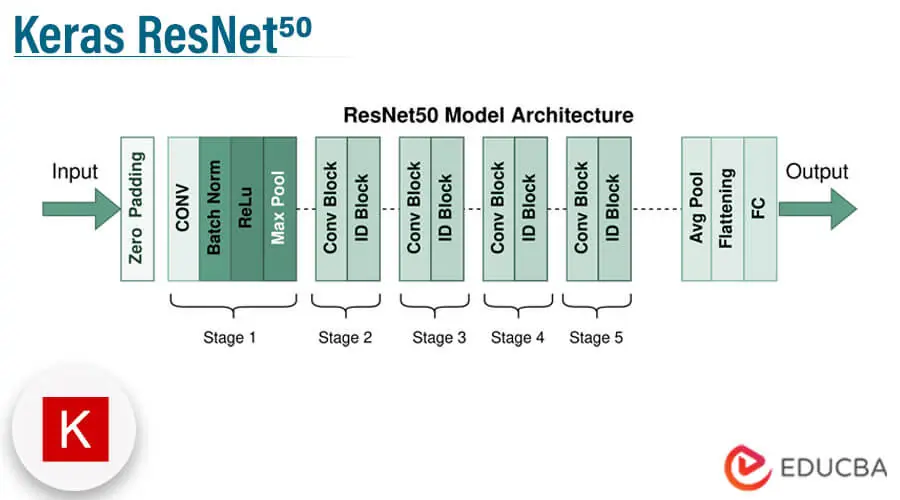


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications import Xception, ResNet50

# Crear el modelo secuencial
model = Sequential()

# Cargar el modelo pre-entrenado Xception sin la capa de clasificación
#xception = Xception(include_top=False, weights='imagenet', input_shape=(100, 100, 3))

# Agregar las capas de Xception al modelo secuencial
#model.add(xception)

# Cargar el modelo pre-entrenado ResNet50 sin la capa de clasificación
resnet = ResNet50(include_top=False, weights='imagenet', input_shape=(299, 299, 3))

# Agregar las capas de ResNet50 al modelo secuencial
model.add(resnet)

# Agregar capas adicionales al modelo secuencial para la clasificación
model.add(GlobalAveragePooling2D())
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(7, activation='softmax'))


Dividir datos: entrenamiento, prueba y validación

In [ ]:
X = dataset[['image_full_name','dx','lesion_id']]
Y = X.pop('dx').to_frame()
X_entre, X_prueba, Y_entre, Y_prueba = train_test_split(X, Y, test_size=0.15, random_state=42)
X_entre, X_val, Y_entre, Y_val = train_test_split(X_entre, Y_entre, test_size=0.15, random_state=42)

In [ ]:
entre = pd.concat([X_entre, Y_entre],axis=1)
val = pd.concat([X_val, Y_val],axis=1)
prueba = pd.concat([X_prueba, Y_prueba],axis=1)

In [ ]:
encoder = LabelEncoder()
encoder.fit(val['dx'])
tipo_indice_entre = encoder.transform(val['dx'])
val['label'] = tipo_indice_entre

In [ ]:
encoder = LabelEncoder()
encoder.fit(prueba['dx'])
tipo_indice_prueba = encoder.transform(prueba['dx'])
prueba['label'] = tipo_indice_prueba

In [ ]:
entre_generator = ImageDataGenerator(rescale=1./255, rotation_range=10, zoom_range = 0.1,
                                     width_shift_range=0.0, height_shift_range=0.00)

In [ ]:
datos_entre = entre_generator.flow_from_dataframe(dataframe=entre, x_col="image_full_name", y_col="dx",
                                                  batch_size=32, directory="HAM1000_images/HAM1000_images",
                                                  shuffle=True, class_mode="categorical", target_size=(28,28))

Found 7235 validated image filenames belonging to 7 classes.


In [ ]:
prueba_generator = ImageDataGenerator(rescale=1./255,rotation_range=10, zoom_range=0.1,
                                      width_shift_range=0.0, height_shift_range=0.02)

In [ ]:
datos_prueba = prueba_generator.flow_from_dataframe(dataframe=prueba, x_col="image_full_name", y_col="dx",
                                                    directory="HAM1000_images/HAM1000_images",
                                                    shuffle=False, batch_size=1, class_mode=None, target_size=(28,28))

Found 1503 validated image filenames.


In [ ]:
datos_val = prueba_generator.flow_from_dataframe(dataframe=val, x_col="image_full_name", y_col="dx",
                                                 directory="HAM1000_images/HAM1000_images",
                                                 batch_size=64, shuffle=False, class_mode="categorical", target_size=(28,28))

Found 1277 validated image filenames belonging to 7 classes.


Compilar modelo

In [ ]:
from tensorflow import keras
sgd = keras.optimizers.SGD(learning_rate=0.01, clipvalue=0.5)
model.compile(optimizer=sgd,loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet50 (Functional)        (None, 10, 10, 2048)      23587712  
_________________________________________________________________
global_average_pooling2d_1 ( (None, 2048)              0         
_________________________________________________________________
flatten (Flatten)            (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 512)               1049088   
_________________________________________________________________
dropout (Dropout)            (None, 512)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 7)                 3591      
Total params: 24,640,391
Trainable params: 24,587,271
Non-trainable params: 53,120
_____________________________________

Entrenar modelo

In [ ]:
historial = model.fit(
    x=datos_entre,
    steps_per_epoch=datos_entre.samples // datos_entre.batch_size,
    validation_data=datos_val,
    validation_steps=datos_val.samples // datos_val.batch_size,
    epochs=30,
    verbose=1
)


Epoch 1/30
226/226 [==============================] - 85s 297ms/step - loss: 1.0873 - accuracy: 0.6614 - val_loss: 1.1985 - val_accuracy: 0.6752
Epoch 2/30
226/226 [==============================] - 55s 244ms/step - loss: 0.9195 - accuracy: 0.6846 - val_loss: 1.3749 - val_accuracy: 0.5551
Epoch 3/30
226/226 [==============================] - 55s 244ms/step - loss: 0.8704 - accuracy: 0.6994 - val_loss: 1.7062 - val_accuracy: 0.1036
Epoch 4/30
226/226 [==============================] - 55s 243ms/step - loss: 0.7993 - accuracy: 0.7176 - val_loss: 1.4616 - val_accuracy: 0.3429
Epoch 5/30
226/226 [==============================] - 55s 243ms/step - loss: 0.7500 - accuracy: 0.7282 - val_loss: 0.9502 - val_accuracy: 0.6891
Epoch 6/30
226/226 [==============================] - 56s 248ms/step - loss: 0.7294 - accuracy: 0.7407 - val_loss: 0.6671 - val_accuracy: 0.7492
Epoch 7/30
226/226 [==============================] - 55s 244ms/step - loss: 0.6877 - accuracy: 0.7468 - val_loss: 0.6699 - val_ac

In [ ]:
datos_val.samples // datos_val.batch_size,


(19,)

Evaluación porcentaje de precisión

In [ ]:
datos_prueba.reset()
predicciones = model.predict_generator(datos_prueba, steps=datos_prueba.samples/datos_prueba.batch_size, verbose=1)
x_pred = np.argmax(predicciones, axis=1)
cant = np.where(x_pred == tipo_indice_prueba)
print(f"Tasa de precision del modelo: {int((np.count_nonzero(cant) / len(tipo_indice_prueba)) * 100)} %")

1503/1503 [==============================] - 114s 75ms/step
Tasa de precision del modelo: 76 %


Guardar modelo

In [ ]:
model.save('Trabajo_Final_Aplic_Resnetv2_299.h5')

C:\Users\hard_\anaconda3\envs\myenv\lib\site-packages\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


In [ ]:
# importar librerias
import os
import tensorflow
import numpy as np
#from werkzeug.utils import secure_filename


# abrir el modelo
modelo = tensorflow.keras.models.load_model('Trabajo_Final_Aplic_Resnetv1.h5')

# indice de los tipos de lesiones
lesion_clases_dicc = {
    0 : 'Melanocytic nevi',
    1 : 'Melanoma',
    2 : 'Benign keratosis-like lesions ',
    3 : 'Basal cell carcinoma',
    4 : 'Actinic keratoses',
    5 : 'Vascular lesions',
    6 : 'Dermatofibroma'
}

# funcion que retorna la prediccion del modelo
def prediccion_modelo(direc_img, modelo):
    c_img = tensorflow.keras.preprocessing.image.load_img(direc_img, target_size=(299,299,3))
    img = tensorflow.keras.preprocessing.image.img_to_array(c_img)
    img = np.expand_dims(img, axis=0)
    print(img)
    predic = modelo.predict(img)
    return predic

In [ ]:
from skimage import io
from tensorflow.keras.preprocessing import image
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
explainer = lime_image.LimeImageExplainer()

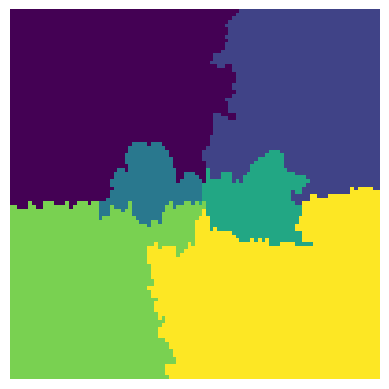

In [ ]:
plt.imshow(explanation.segments)
plt.axis('off')
plt.show()

# Explicabilidad

In [ ]:
def LIME_Model_tag_explication(modelo,url_img,size_img = (100, 100)):
    normalized_img = transform_image(url_img, size_img)

    img = normalized_img.astype('double')

    explanation = explainer.explain_instance(img[0], modelo.predict,top_labels=7, hide_color=0, num_samples=1000)

    # Realizar la predicción
    predictions = modelo.predict(img)

    # Obtener las probabilidades para cada etiqueta
    label_probabilities = predictions[0]

    #Etiquetas
    lesion_clases_dicc = {
        0 : 'Melanocytic nevi',
        1 : 'Melanoma',
        2 : 'Benign keratosis-like lesions ',
        3 : 'Basal cell carcinoma',
        4 : 'Actinic keratoses',
        5 : 'Vascular lesions',
        6 : 'Dermatofibroma'
    }

    #Numero de axes
    fig, arr = plt.subplots(7, 2, figsize=(15, 40))
    plt.subplots_adjust(hspace=0.3, wspace=0.1)

    #Mostramos la relacion de cada etiqueta con la imagen
    for i,im in enumerate(explanation.top_labels):
        temp_1, mask_1 = explanation.get_image_and_mask(im, positive_only=True, num_features=5, hide_rest=True)
        temp_2, mask_2 = explanation.get_image_and_mask(im, positive_only=False, num_features=10,hide_rest=False)

        arr[i][0].imshow((mark_boundaries(temp_1, mask_1)*255).astype(np.uint8))
        arr[i][1].imshow((mark_boundaries(temp_2, mask_2)*255).astype(np.uint8))
        arr[i][0].axis('off')
        arr[i][1].axis('off')
        arr[i][0].set_title('Positivo ambos - {}\nProbabilidad: {}'.format(lesion_clases_dicc[im],label_probabilities[im]))
        arr[i][1].set_title('Negativo ambos - {}\nProbabilidad: {}'.format(lesion_clases_dicc[im],label_probabilities[im]))

### Carga del modelo
Cargamos el modelo pre entrenado con Resnet50 y luego ejecutamos la funcion para generar la explicabilidad

In [ ]:
import skimage
def transform_image(url,size_im):
    img = skimage.io.imread(url)
    img = skimage.transform.resize(img, size_im)

    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    return img

### Primera Prueba
#### Resnet50 con input_shape = (100,100)

  0%|          | 0/1000 [00:00<?, ?it/s]

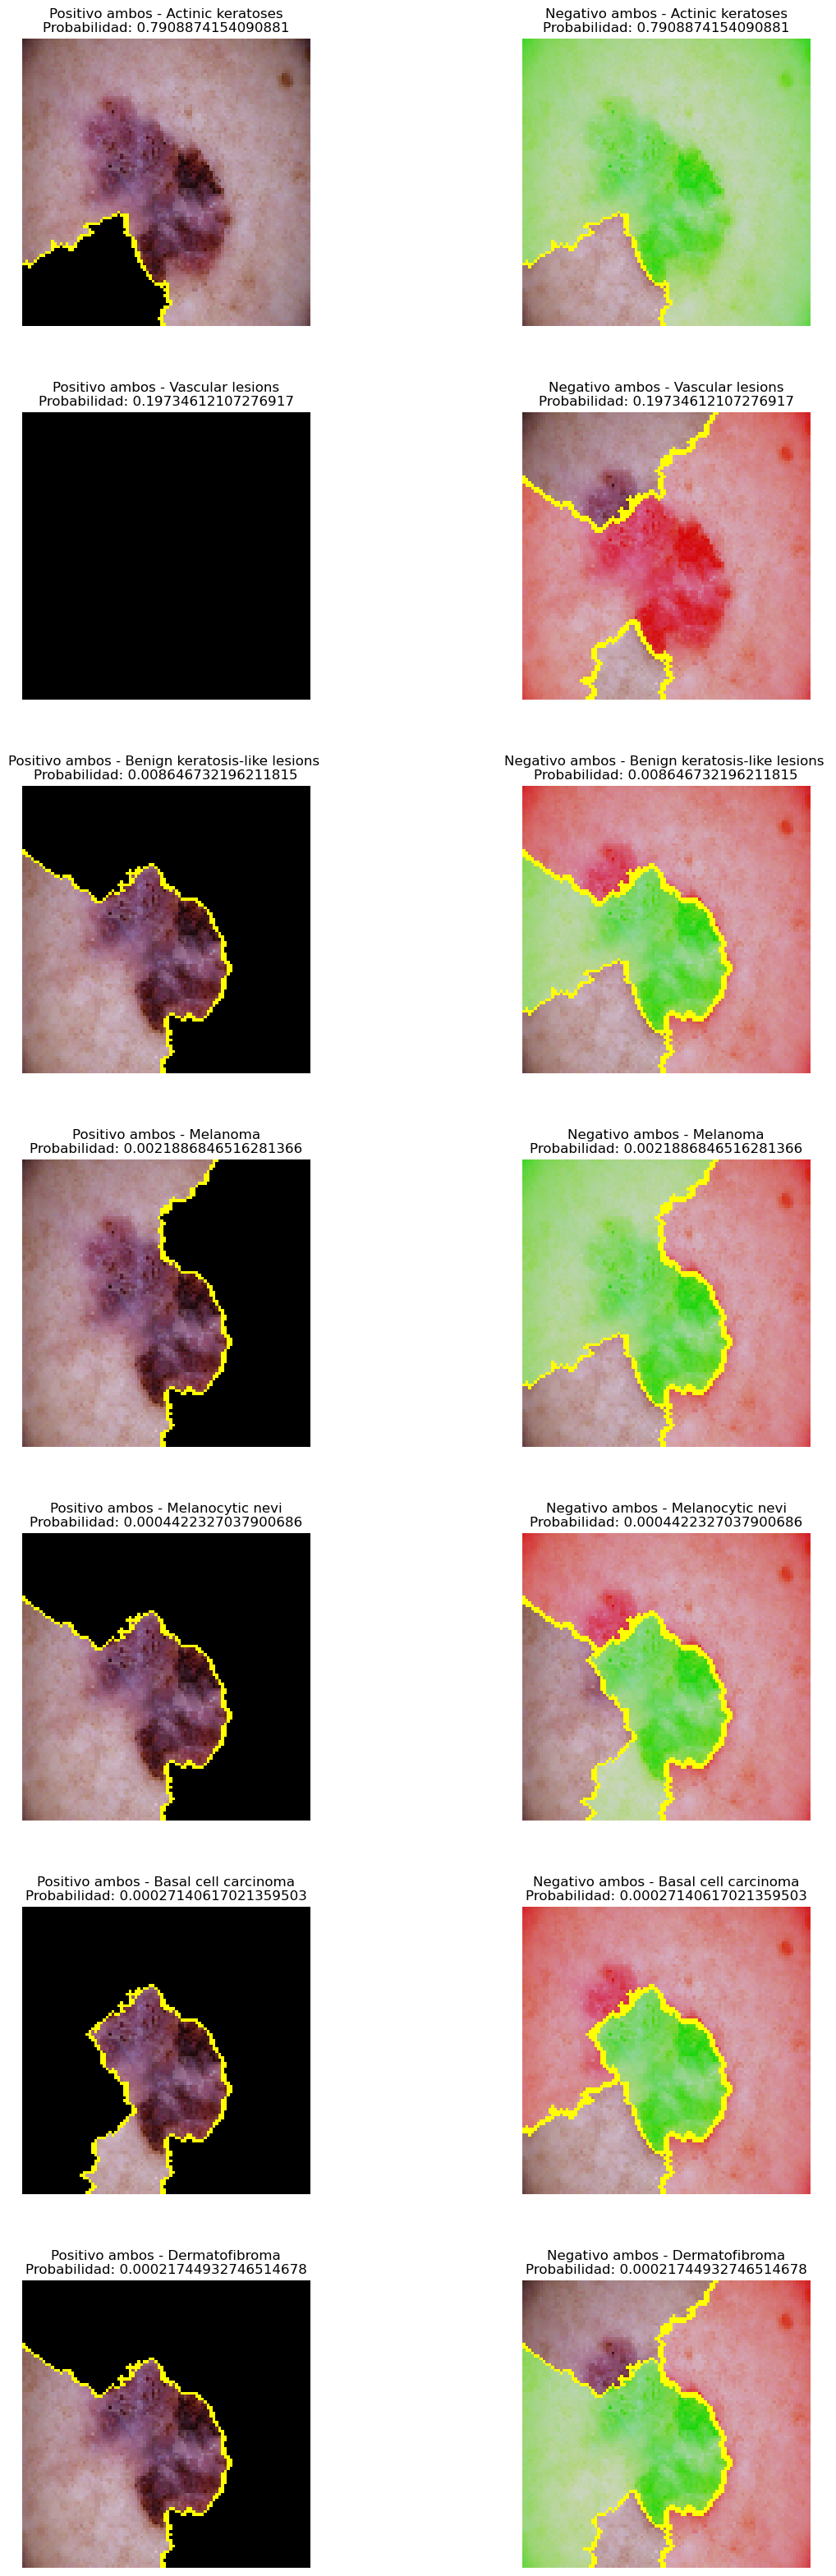

In [ ]:
model = tensorflow.keras.models.load_model('Trabajo_Final_Aplic_Resnetv1.h5')
LIME_Model_tag_explication(model,'ISIC_0034316.jpg')

#### Resnet50 con input_shape = (299,299)

  0%|          | 0/1000 [00:00<?, ?it/s]

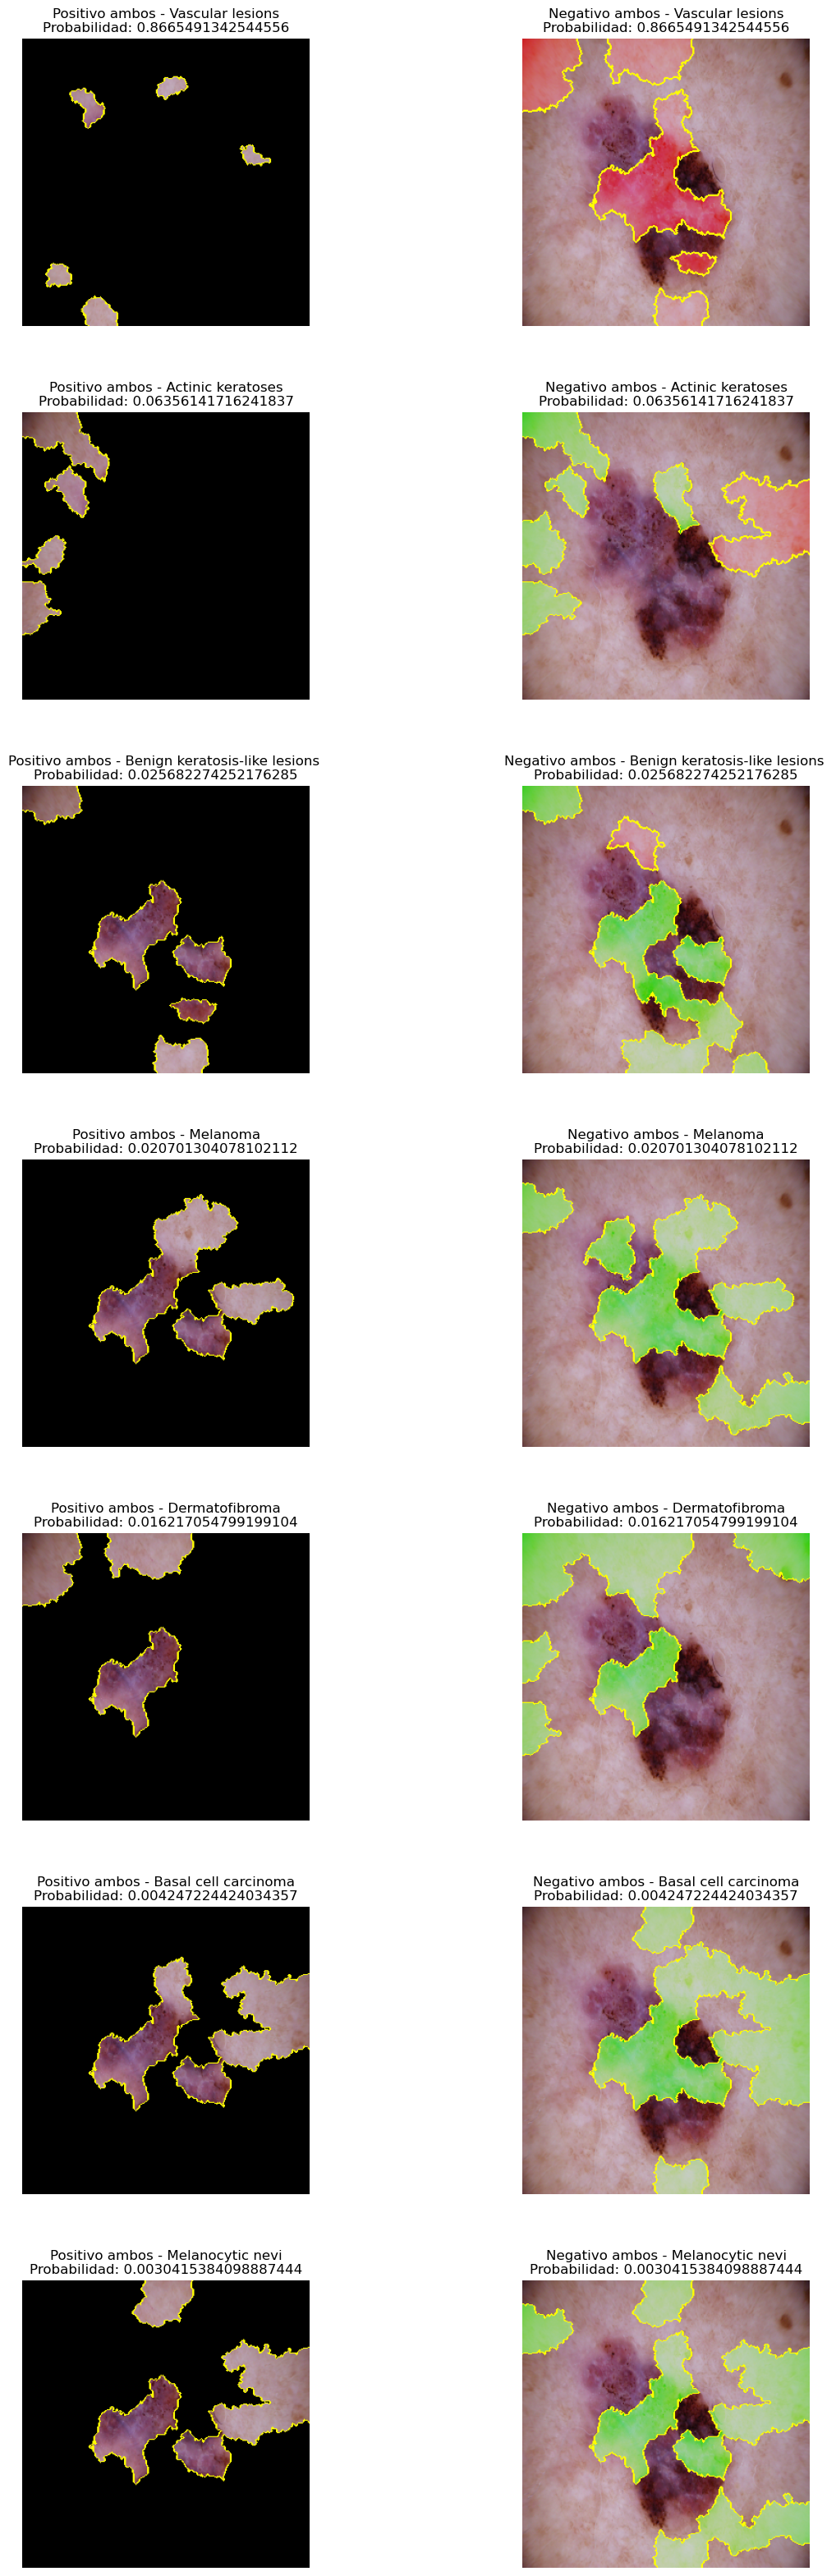

In [ ]:
model = tensorflow.keras.models.load_model('Trabajo_Final_Aplic_Resnetv2_299.h5')
LIME_Model_tag_explication(model,'ISIC_0034316.jpg',(299,299))

### Segunda Prueba
#### Resnet50 con input_shape = (100,100)

  0%|          | 0/1000 [00:00<?, ?it/s]

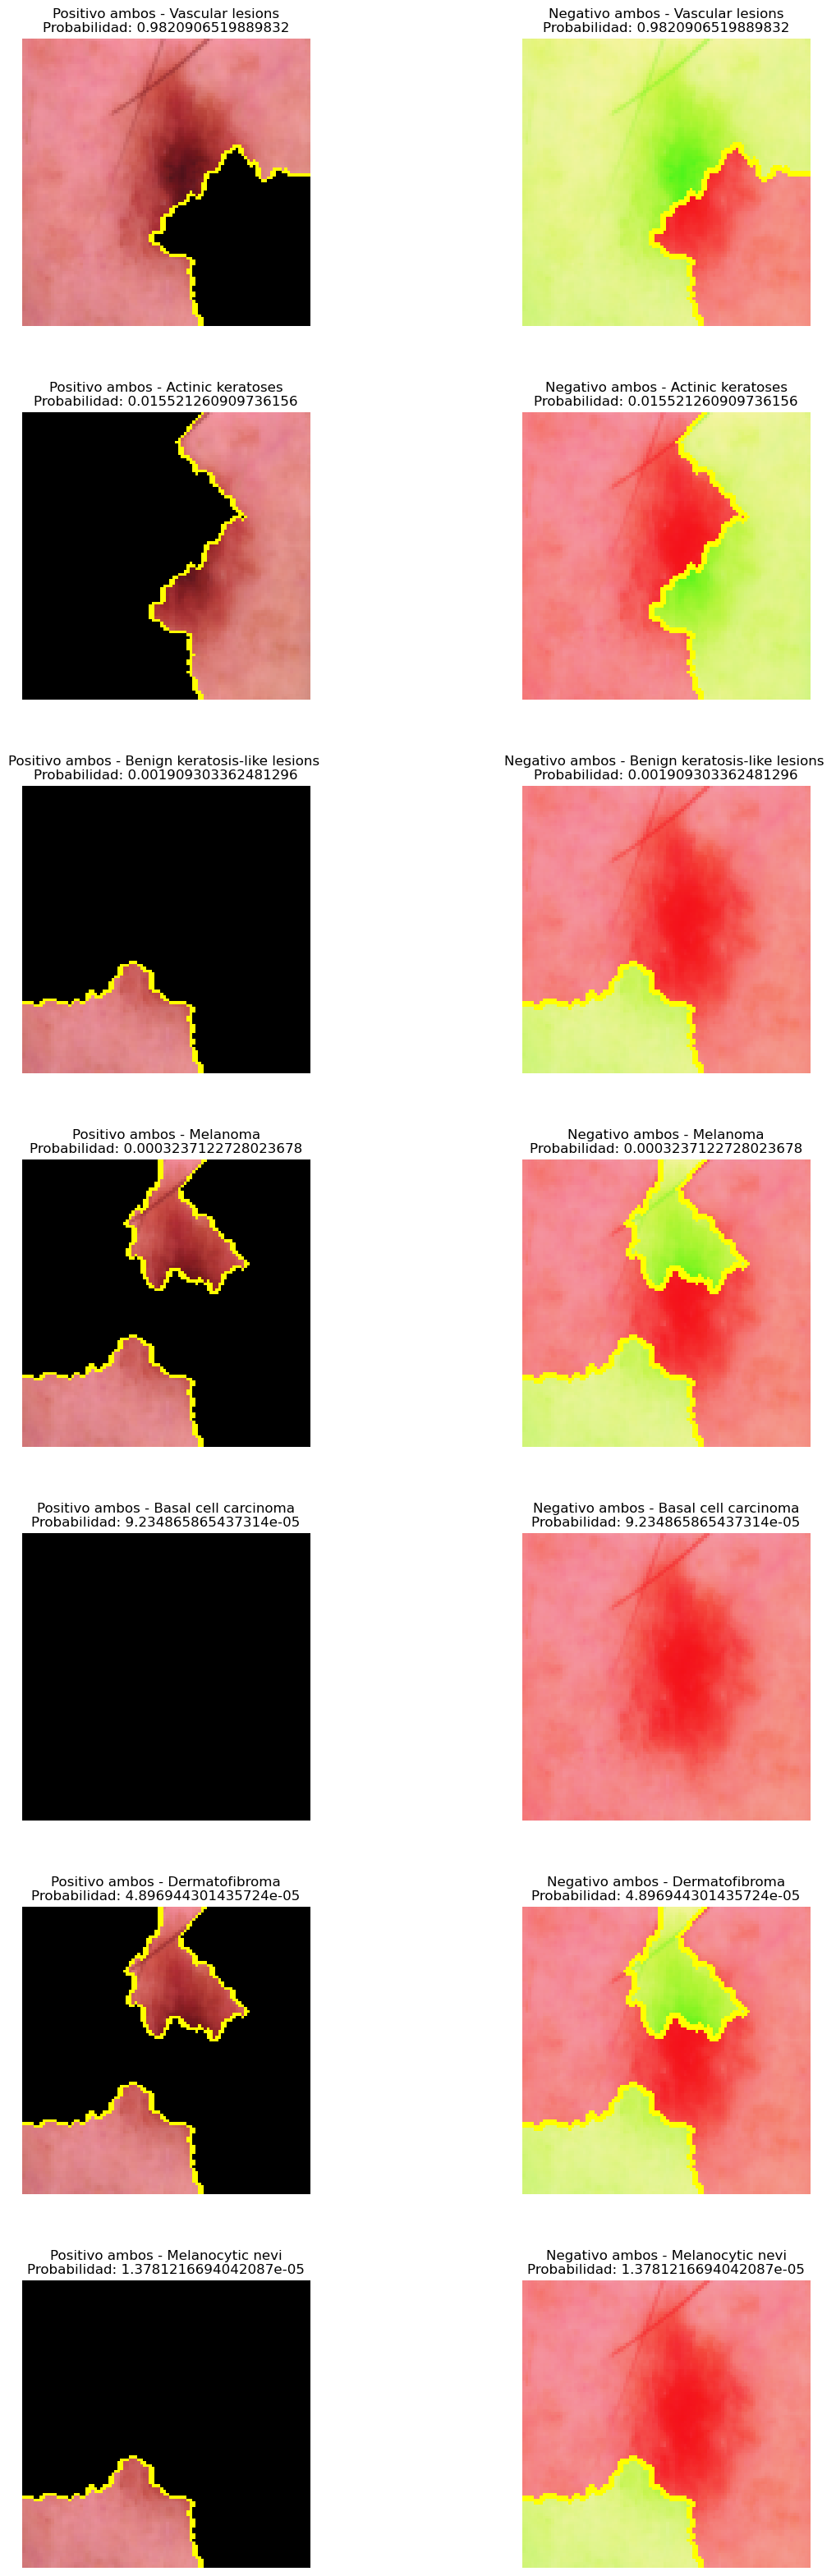

In [ ]:
model = tensorflow.keras.models.load_model('Trabajo_Final_Aplic_Resnetv1.h5')
LIME_Model_tag_explication(model,'HAM1000_images/HAM1000_images/ISIC_0024306.jpg')

#### Resnet50 con input_shape = (299,299)

  0%|          | 0/1000 [00:00<?, ?it/s]

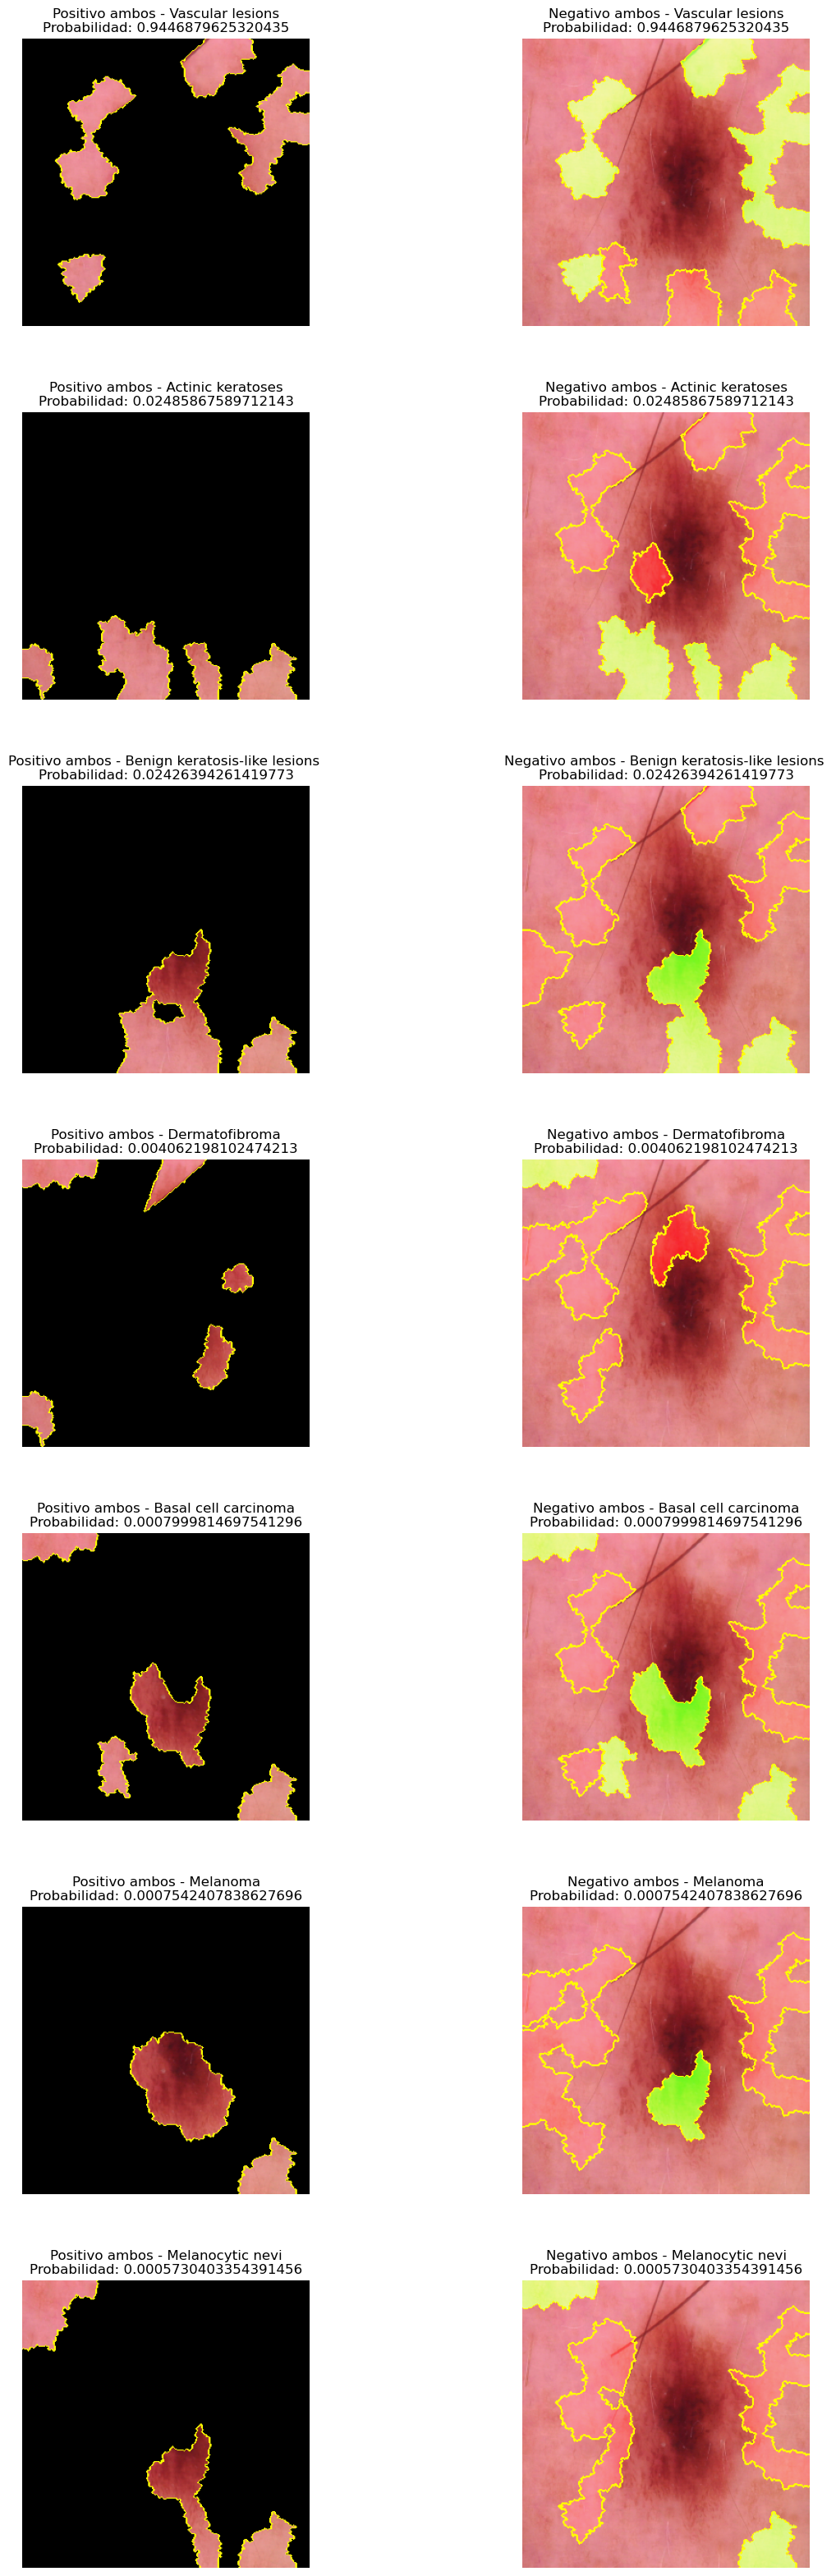

In [ ]:
model = tensorflow.keras.models.load_model('Trabajo_Final_Aplic_Resnetv2_299.h5')
LIME_Model_tag_explication(model,'HAM1000_images/HAM1000_images/ISIC_0024306.jpg',(299,299))

### Tercera Prueba
#### Resnet50 con input_shape = (100,100)

  0%|          | 0/1000 [00:00<?, ?it/s]

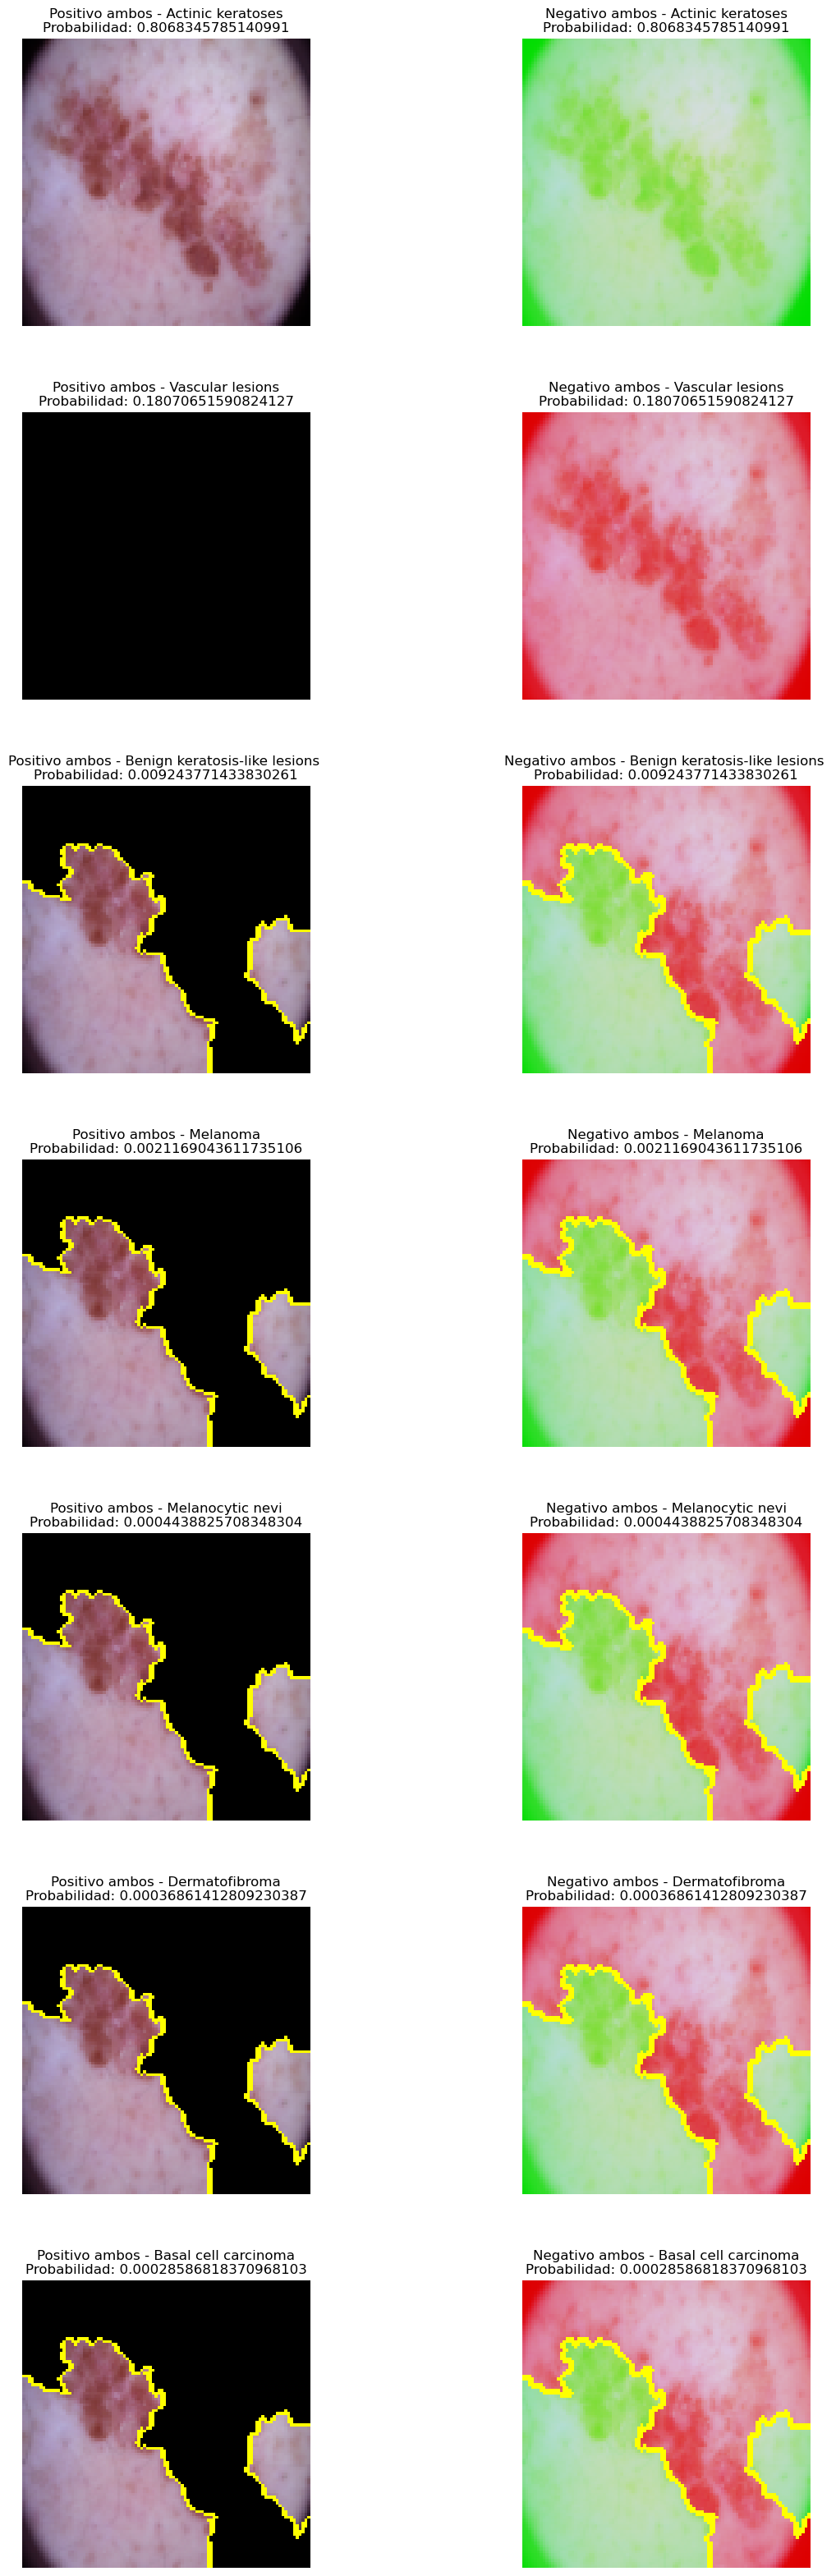

In [ ]:
model = tensorflow.keras.models.load_model('Trabajo_Final_Aplic_Resnetv1.h5')
LIME_Model_tag_explication(model,'ISIC_0034315.jpg')

#### Resnet50 con input_shape = (299,299)

  0%|          | 0/1000 [00:00<?, ?it/s]

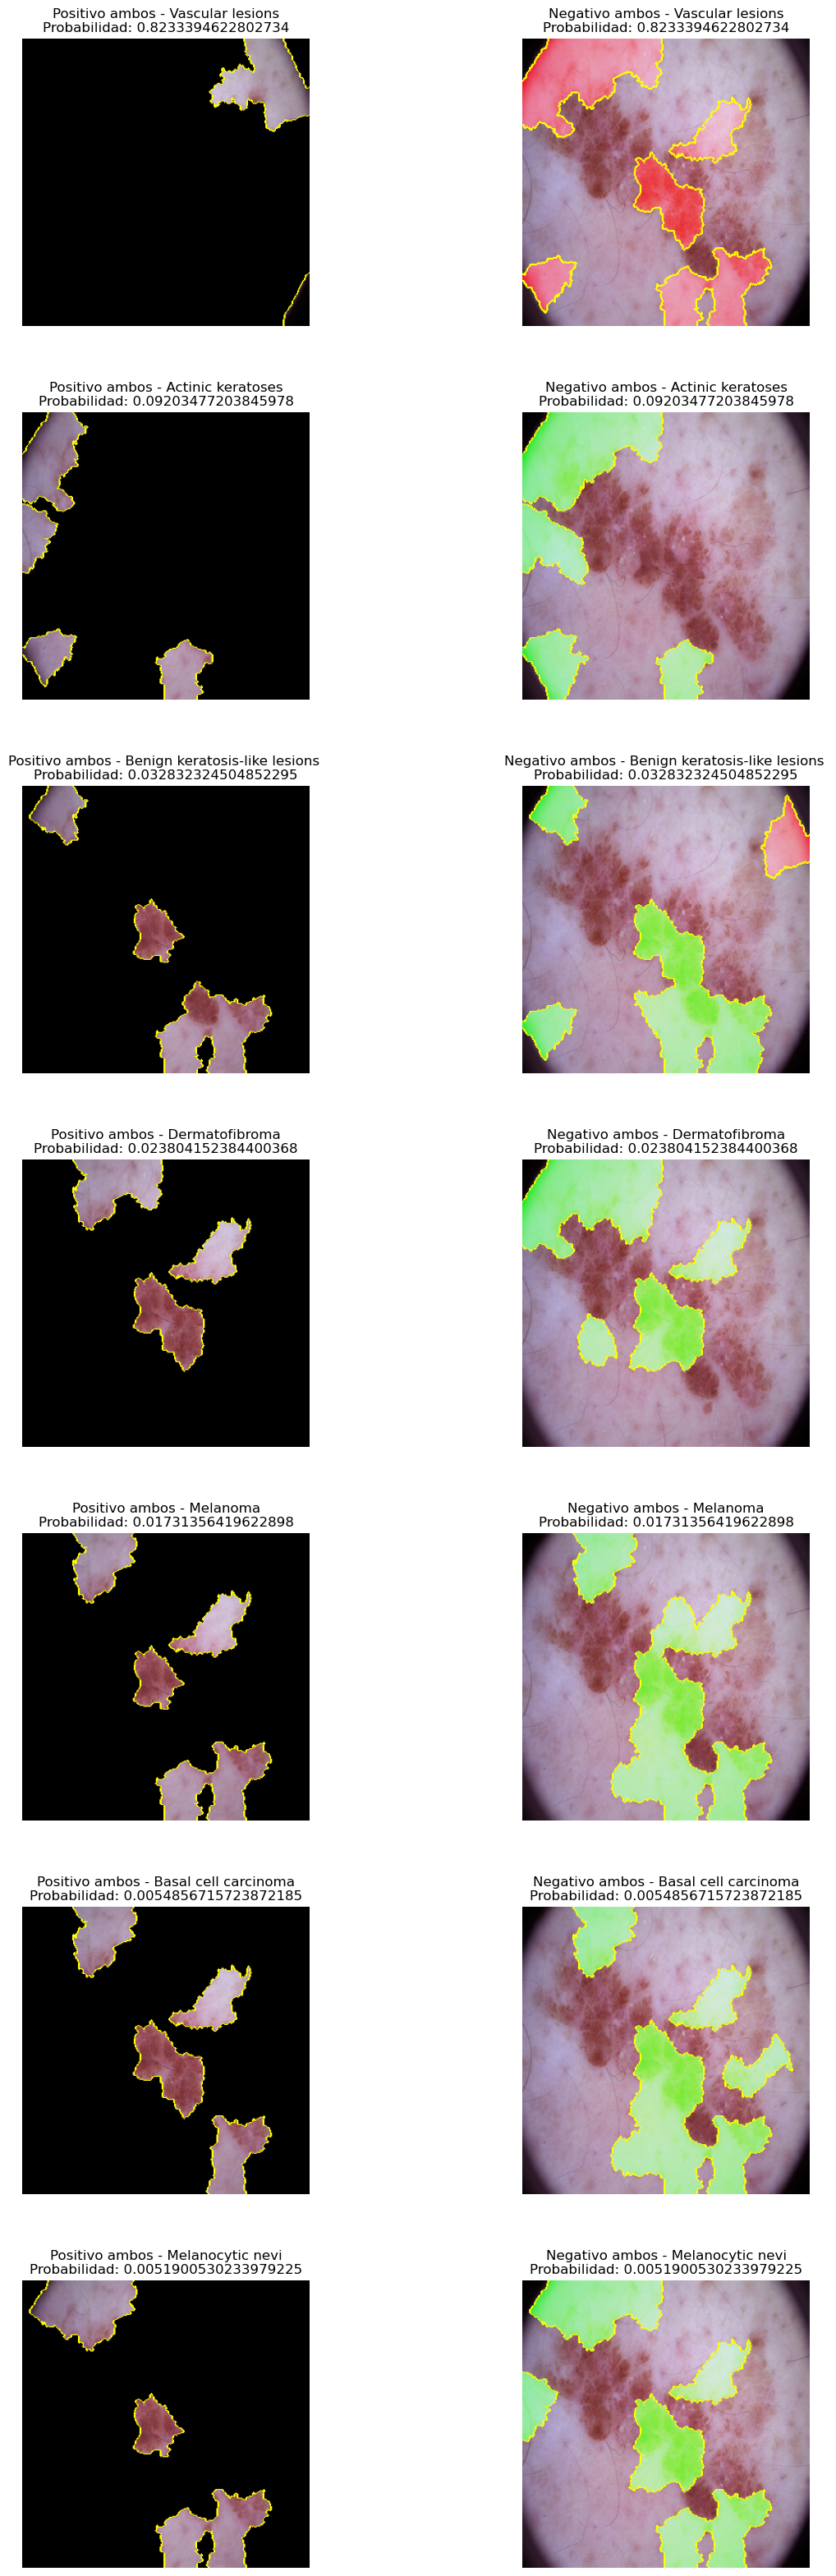

In [ ]:
model = tensorflow.keras.models.load_model('Trabajo_Final_Aplic_Resnetv2_299.h5')
LIME_Model_tag_explication(model,'ISIC_0034315.jpg',(299,299))

## CONCLUSIONES:

Se uso un modelo de Resnet50, el cual se adapto para que tenga un output de 7 salidas.
Se hicieron dos versiones. La primera tenia un tamaño de entrada de 100 100 3. Y la segunda de 299 299 3.

Para poder entender como funciona cada uno de los modelos, hemos realizado la explicabilidad con LIME. Se ejecuto con las 7 etiquetas.

Podemon notar como el modelo de 100 100 3. Da resultados, y muestra de una manera muy general los tramos para su prediccion. Tomemos como ejemplo la segunda prueba, en donde si nos fijamos el modelo de 100x100 obtiene grandes tramos de la imagen que demuestran su prediccion. Mientras que el modelo de 299x299, es mas exacto. Pues elige tramos mas especificos de la imagen. Sin embargo, este no coge los tramos que nosotros bajo nuestro juicio considermos que lo deberia tomar para que la prediccion sea eficaz. En cambio, con el modelo 100x100, aunque abarca mucho si toma estas porciones. En conclusion, el primero abarca mucho pero es eficiente bajo nuestra perspectiva. Y el segundo es mas detallado pero menos eficiente.

In [ ]:
model = tensorflow.keras.models.load_model('Trabajo_Final_Aplic_Resnetv2_299.h5')
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet50 (Functional)        (None, 10, 10, 2048)      23587712  
_________________________________________________________________
global_average_pooling2d_1 ( (None, 2048)              0         
_________________________________________________________________
flatten (Flatten)            (None, 2048)              0         
_________________________________________________________________
dense (Dense)                (None, 512)               1049088   
_________________________________________________________________
dropout (Dropout)            (None, 512)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 7)                 3591      
Total params: 24,640,391
Trainable params: 24,587,271
Non-trainable params: 53,120
_____________________________________

In [ ]:
model = tensorflow.keras.models.load_model('Trabajo_Final_Aplic_Resnetv1.h5')
model.summary()

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
resnet50 (Functional)        (None, 4, 4, 2048)        23587712  
_________________________________________________________________
global_average_pooling2d_4 ( (None, 2048)              0         
_________________________________________________________________
flatten_3 (Flatten)          (None, 2048)              0         
_________________________________________________________________
dense_11 (Dense)             (None, 512)               1049088   
_________________________________________________________________
dropout_1 (Dropout)          (None, 512)               0         
_________________________________________________________________
dense_12 (Dense)             (None, 7)                 3591      
Total params: 24,640,391
Trainable params: 24,587,271
Non-trainable params: 53,120
_____________________________________

La explicabilidad del dataset

* Origen y recopilación de datos: Es importante entender cómo se recopilaron las imágenes y cómo se etiquetaron. El dataset HAM10000 fue creado por expertos dermatólogos y se recopiló de pacientes en diversos centros médicos. Conocer estos detalles proporciona información sobre la calidad y confiabilidad de los datos.

* Características y distribución de las imágenes: Es fundamental analizar las características de las imágenes presentes en el dataset, como el tamaño, la resolución y las condiciones de iluminación. También es importante comprender la distribución de las clases (melanoma y no melanoma) y cualquier posible desequilibrio entre ellas.

* Anotaciones y etiquetas: La explicabilidad también implica comprender las anotaciones y etiquetas asociadas a cada imagen. En el caso del dataset HAM10000, las imágenes están etiquetadas con diagnósticos dermatológicos y se proporciona información adicional como edad y género del paciente. Comprender cómo se realizaron estas anotaciones puede ayudar a evaluar la confiabilidad y la interpretación de los resultados del modelo.

* Consideraciones éticas: La explicabilidad del dataset también puede abordar aspectos éticos relacionados con la privacidad y la protección de datos. Al tratarse de datos médicos sensibles, es importante considerar cómo se obtuvieron los consentimientos informados y cómo se protege la privacidad de los pacientes involucrados en el dataset.

## Link de dataset

https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000